# QUESTION 2: Employee Analytics

In [3]:
# Dataset Creation

import numpy as np;
import pandas as pd;

np.random.seed(10);

df = pd.DataFrame({
    "employee_id": range(1, 501),
    "experience_years": np.random.randint(0, 20, 500),
    "salary": np.random.randint(20000, 150000, 500),
    "performance_rating": np.random.randint(1, 6, 500),
    "department": np.random.choice(["IT", "HR", "Sales", "Finance"], 500)
})

# Inspection :

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         500 non-null    int64 
 1   experience_years    500 non-null    int64 
 2   salary              500 non-null    int64 
 3   performance_rating  500 non-null    int64 
 4   department          500 non-null    object
dtypes: int64(4), object(1)
memory usage: 19.7+ KB


In [3]:
df.describe(include='all')

,employee_id,experience_years,salary,performance_rating,department
count,500.000000,500.000000,500.000000,500.000000,500
unique,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,HR
freq,NaN,NaN,NaN,NaN,128
mean,250.500000,9.768000,85734.504000,2.974000,NaN
std,144.481833,5.896415,37764.998663,1.421748,NaN
min,1.000000,0.000000,20135.000000,1.000000,NaN
25%,125.750000,5.000000,53242.000000,2.000000,NaN
50%,250.500000,10.000000,86474.000000,3.000000,NaN
75%,375.250000,15.000000,118165.250000,4.000000,NaN


In [ ]:
# GroupBy with multiple columns :

df.groupby("department")["salary"].agg('mean', 'median', 'max');

,salary
department,
Finance,81765.471074
HR,89800.867188
IT,85814.166667
Sales,85332.272000


In [ ]:
# Pivot table

pd.pivot_table(
    df,
    values="salary",
    index="department",
    columns="performance_rating",
    aggfunc="mean"
)

performance_rating,1,2,3,4,5
department,,,,,
Finance,82720.923077,76804.807692,83619.500000,82036.041667,84187.920000
HR,97866.692308,90268.281250,85418.960000,79886.210526,92618.461538
IT,90444.909091,79540.033333,91832.444444,79517.652174,88675.583333
Sales,85739.111111,102458.947368,89882.800000,75612.714286,78485.846154


In [17]:
# Ranking

df["salary_rank"] = df["salary"].rank(ascending=False);
print(df);

     employee_id  experience_years  salary  performance_rating department  \
0              1                 9   62081                   5    Finance   
1              2                 4  120202                   5         IT   
2              3                15  109651                   3    Finance   
3              4                 0   70175                   2         HR   
4              5                17   59493                   2    Finance   
..           ...               ...     ...                 ...        ...   
495          496                 4   31399                   2         IT   
496          497                 2   37467                   2    Finance   
497          498                15   22203                   5      Sales   
498          499                 9   40389                   3         IT   
499          500                 7   27820                   5      Sales   

     salary_rank   level  
0          348.0  Junior  
1          119.0  Jun

In [16]:
# Conditional column

df['level'] = np.where(df['experience_years'] >= 10, "Senior", "Junior")
print(df)

     employee_id  experience_years  salary  performance_rating department  \
0              1                 9   62081                   5    Finance   
1              2                 4  120202                   5         IT   
2              3                15  109651                   3    Finance   
3              4                 0   70175                   2         HR   
4              5                17   59493                   2    Finance   
..           ...               ...     ...                 ...        ...   
495          496                 4   31399                   2         IT   
496          497                 2   37467                   2    Finance   
497          498                15   22203                   5      Sales   
498          499                 9   40389                   3         IT   
499          500                 7   27820                   5      Sales   

     salary_rank   level  
0          348.0  Junior  
1          119.0  Jun

In [18]:
# Value counts
df['department'].value_counts(normalize=True)

,proportion
department,
HR,0.256
IT,0.252
Sales,0.250
Finance,0.242


### Visualization

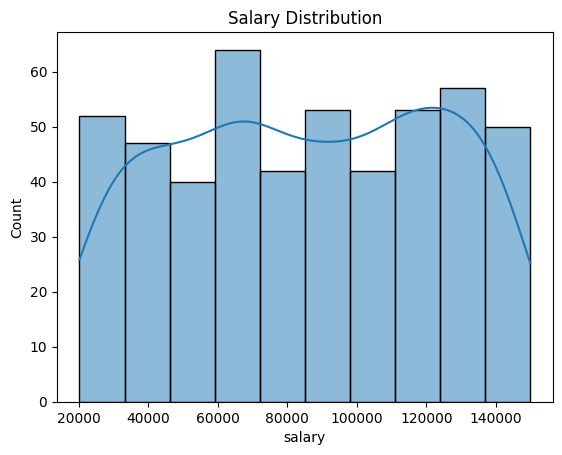

In [5]:
# Salary distribution  -

import matplotlib.pyplot as plt
import seaborn as sns;

sns.histplot(df["salary"], kde=True)
plt.title("Salary Distribution");
plt.show()

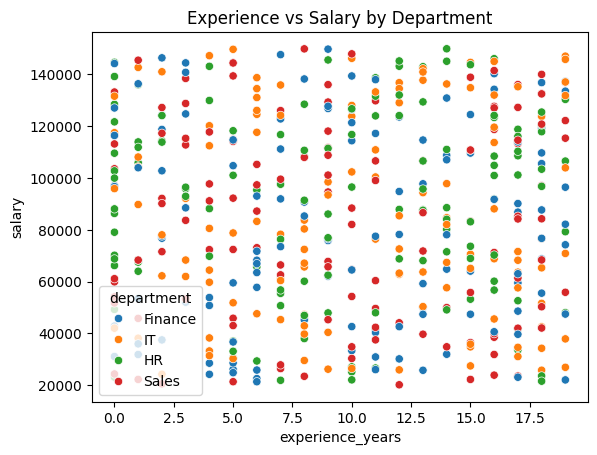

In [7]:
# Experience vs Salary

sns.scatterplot(x="experience_years", y="salary", hue="department", data=df)
plt.title("Experience vs Salary by Department")
plt.show()

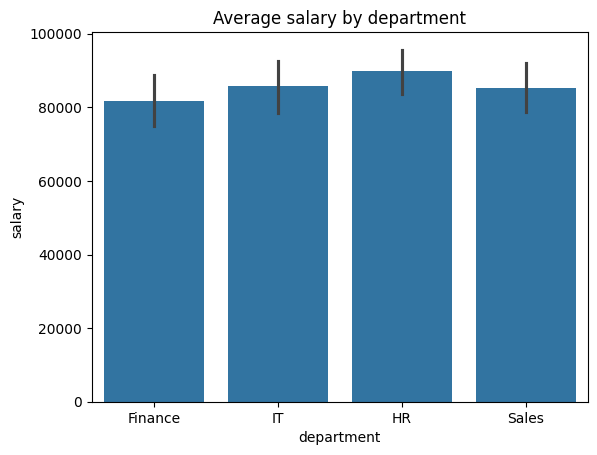

In [8]:
# Bar plot

sns.barplot(x='department', y='salary', data=df);
plt.title("Average salary by department");
plt.show()

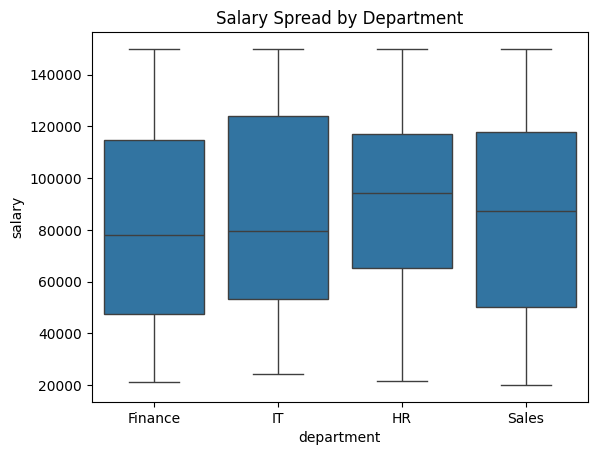

In [9]:
# Boxplot

sns.boxplot(x='department', y='salary', data=df);
plt.title("Salary Spread by Department")
plt.show();